# 7. Moments of the Stochastic Heat Equation

In Notebook 6, we studied how spatially correlated noise affects individual solutions of the stochastic heat equation.

In this notebook, we move from individual realizations to moment statistics. We compute spatial moments along a single sample path, estimate their expectations using Monte Carlo simulation, and investigate how the second moment depends on the correlation length.

## Objectives

In this notebook we will

- compute spatial moments of the numerical solution,
- distinguish single-path moments from ensemble averages,
- estimate the first and second moments using Monte Carlo simulation, and
- investigate the effect of the correlation length on the second moment.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Spatial grid
N = 100
h = 1 / N
x = np.arange(N) * h

# Model parameters
kappa = 0.5
sigma = 1.0

# Time discretization
dt = 0.2 * h**2
T = 0.05
num_steps = int(T / dt)

# Output
record_every = 10

# Initial condition
u0 = np.ones(N)

In [3]:
def covariance_matrix(x, ell):
    """
    Construct the exponential covariance matrix
    on a one-dimensional periodic domain.
    """
    N = len(x)
    h = x[1] - x[0]
    domain_length = N * h

    Q = np.zeros((N, N))

    for i in range(N):
        for j in range(N):
            distance = abs(x[i] - x[j])
            periodic_distance = min(
                distance,
                domain_length - distance,
            )

            Q[i, j] = np.exp(
                -periodic_distance / ell
            )

    return Q

In [4]:
def laplacian(u, h):
    """Compute the one-dimensional periodic discrete Laplacian."""
    return (np.roll(u, -1) - 2 * u + np.roll(u, 1)) / h**2

In [5]:
def solve_colored_stochastic_heat_equation(
    u0,
    h,
    dt,
    num_steps,
    L,
    kappa=0.5,
    sigma=1.0,
    record_every=10,
    rng=None,
):
    """
    Solve the one-dimensional stochastic heat equation
    with spatially correlated Gaussian noise.
    """
    if rng is None:
        rng = np.random.default_rng()

    u = u0.copy()

    snapshots = [u.copy()]
    times = [0.0]

    for n in range(num_steps):
        z = rng.normal(size=u.size)
        noise_sample = L @ z

        dW = sigma * np.sqrt(dt / h) * noise_sample

        diffusion = kappa * dt * laplacian(u, h)
        stochastic_term = u * dW

        u += diffusion + stochastic_term

        if (n + 1) % record_every == 0:
            snapshots.append(u.copy())
            times.append((n + 1) * dt)

    return {
        "solution": u,
        "snapshots": np.array(snapshots),
        "times": np.array(times),
    }

## Mathematical Background

### Spatial Moments

For a numerical solution $u(t,x)$, we define the spatially averaged $p$-th moment by

$$
M_p(t)
=
\frac{1}{N}
\sum_{i=1}^{N}
u(t,x_i)^p.
$$

For a single realization, $M_p(t)$ remains random and depends on the particular noise sample.

We will focus on the first and second spatial moments.

### Monte Carlo Moments

To study the average behavior across independent realizations, we estimate the expectation of the spatial moment by

$$
m_p(t)
=
\mathbb{E}[M_p(t)].
$$

Using $R$ independent simulations, the Monte Carlo estimator is

$$
\widehat{m}_p(t)
=
\frac{1}{R}
\sum_{r=1}^{R}
M_p^{(r)}(t).
$$

The first moment describes the average level of the solution, while the second moment captures the magnitude of its fluctuations.

## Numerical Method

The spatially correlated stochastic heat equation is simulated using the same finite-difference and Euler--Maruyama discretization as in the previous notebook.

For each realization, the spatial moment is computed at every recorded time. Repeating the simulation independently and averaging the resulting moment paths gives the Monte Carlo estimate $\widehat{m}_p(t)$.

In [6]:
def spatial_moment(snapshots, p):
    """Compute the spatially averaged p-th moment at each recorded time."""
    return np.mean(snapshots**p, axis=1)

In [7]:
def mc_moment(
    p,
    num_simulations,
    u0,
    h,
    dt,
    num_steps,
    L,
    kappa=0.5,
    sigma=1.0,
    record_every=10,
    seed=42,
):
    """Estimate the p-th spatial moment using Monte Carlo simulation."""
    sum_moment = None
    times = None

    for simulation in range(num_simulations):
        result = solve_colored_stochastic_heat_equation(
            u0,
            h,
            dt,
            num_steps,
            L,
            kappa=kappa,
            sigma=sigma,
            record_every=record_every,
            rng=np.random.default_rng(seed + simulation),
        )

        moment_path = spatial_moment(result["snapshots"], p)

        if sum_moment is None:
            times = result["times"]
            sum_moment = np.zeros_like(moment_path)

        sum_moment += moment_path

    empirical_moment = sum_moment / num_simulations

    return times, empirical_moment

## Numerical Experiments

### Single-Path Moments

We first consider one realization with correlation length

$$
\ell=0.05.
$$

The first and second spatial moments fluctuate over time and reflect the behavior of this particular realization.

In [8]:
ell = 0.05

Q = covariance_matrix(x, ell)
L = np.linalg.cholesky(Q)

seed = 42

In [9]:
result = solve_colored_stochastic_heat_equation(
    u0,
    h,
    dt,
    num_steps,
    L,
    kappa=kappa,
    sigma=sigma,
    record_every=record_every,
    rng=np.random.default_rng(seed),
)

In [10]:
snapshots = result["snapshots"]
times = result["times"]

first_moment_path = spatial_moment(snapshots, p=1)

second_moment_path = spatial_moment(snapshots, p=2)

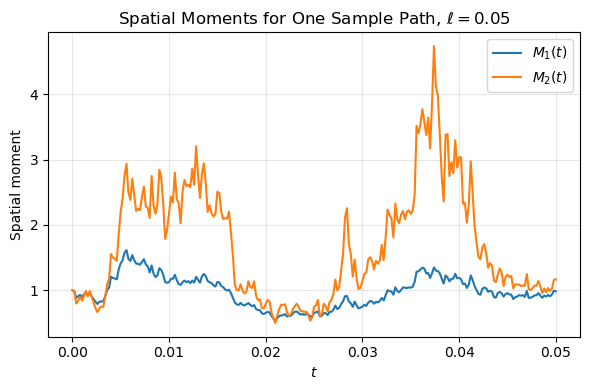

In [11]:
plt.figure(figsize=(6, 4))

plt.plot(
    times,
    first_moment_path,
    label=r"$M_1(t)$",
)

plt.plot(
    times,
    second_moment_path,
    label=r"$M_2(t)$",
)

plt.xlabel(r"$t$")
plt.ylabel("Spatial moment")
plt.title(
    rf"Spatial Moments for One Sample Path, $\ell={ell}$"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Monte Carlo Moment Estimates

We now average over independent realizations to estimate the first and second moments.

The Monte Carlo average reduces the sample-to-sample variability present in a single realization and provides an estimate of the ensemble behavior.

The first moment remains close to its initial level, while the second moment increases, reflecting the growth of fluctuations in the stochastic solution.

In [12]:
num_simulations = 200

times, empirical_first_moment = mc_moment(
    p=1,
    num_simulations=num_simulations,
    u0=u0,
    h=h,
    dt=dt,
    num_steps=num_steps,
    L=L,
    kappa=kappa,
    sigma=sigma,
    record_every=record_every,
    seed=seed,
)

_, empirical_second_moment = mc_moment(
    p=2,
    num_simulations=num_simulations,
    u0=u0,
    h=h,
    dt=dt,
    num_steps=num_steps,
    L=L,
    kappa=kappa,
    sigma=sigma,
    record_every=record_every,
    seed=seed,
)

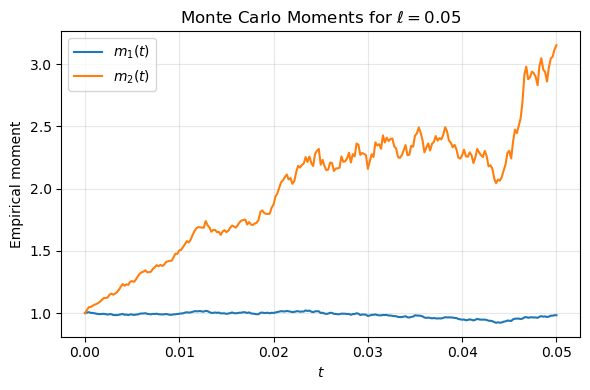

In [13]:
plt.figure(figsize=(6, 4))

plt.plot(
    times,
    empirical_first_moment,
    label=r"$m_1(t)$",
)

plt.plot(
    times,
    empirical_second_moment,
    label=r"$m_2(t)$",
)

plt.xlabel(r"$t$")
plt.ylabel("Empirical moment")
plt.title(
    rf"Monte Carlo Moments for $\ell={ell}$"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Effect of the Correlation Length

Finally, we compare the Monte Carlo estimate of the second moment for

$$
\ell \in \{0.01,\,0.05,\,0.20\}.
$$

The same underlying random seeds are used for each correlation length so that the covariance structure is the main changing parameter.

The second-moment curves differ across the three correlation lengths, showing that the spatial covariance structure affects the moment behavior of the solution. The effect becomes more visible as the simulation evolves.

In [14]:
ells = [0.01, 0.05, 0.20]

cholesky_factors = {
    ell_value: np.linalg.cholesky(
        covariance_matrix(x, ell_value)
    )
    for ell_value in ells
}

In [15]:
second_moments_by_ell = {}

for ell_value in ells:
    _, second_moments_by_ell[ell_value] = mc_moment(
        p=2,
        num_simulations=num_simulations,
        u0=u0,
        h=h,
        dt=dt,
        num_steps=num_steps,
        L=cholesky_factors[ell_value],
        kappa=kappa,
        sigma=sigma,
        record_every=record_every,
        seed=seed,
    )

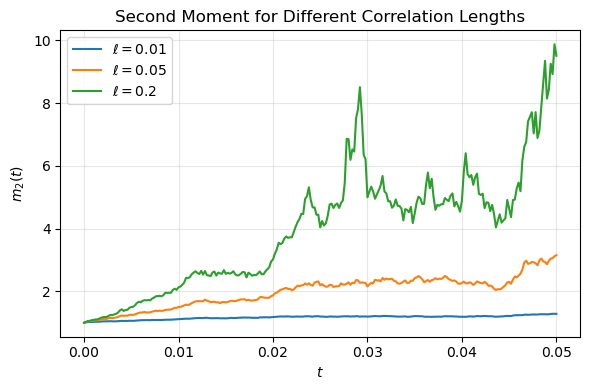

In [16]:
plt.figure(figsize=(6, 4))

for ell_value in ells:
    plt.plot(
        times,
        second_moments_by_ell[ell_value],
        label=rf"$\ell={ell_value}$",
    )

plt.xlabel(r"$t$")
plt.ylabel(r"$m_2(t)$")
plt.title("Second Moment for Different Correlation Lengths")

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "figures/second_moment_correlation_length.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

## Summary

In this notebook, we studied moment statistics of the stochastic heat equation driven by spatially correlated Gaussian noise.

We distinguished spatial moments along a single realization from ensemble moments estimated using Monte Carlo simulation. The first and second moments were estimated numerically, and the second moment was compared across different correlation lengths.

Together with the previous notebooks, this completes the progression from deterministic heat flow to stochastic forcing, Monte Carlo analysis, and spatially correlated noise.